In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [13]:
import os

print(os.listdir('/content'))

Saving student-mat.csv to student-mat.csv


In [14]:
import os

print(os.listdir('/content'))

['.config', 'student-mat.csv', '.student.zip_old', 'student.zip', 'sample_data']


In [15]:
import os

print(os.listdir('/content'))

['.config', 'student-mat.csv', '.student.zip_old', 'student.zip', 'sample_data']


In [16]:
import pandas as pd

df_math = pd.read_csv(
    '/content/student-mat.csv',
    sep=';'
)

print("Mathematics dataset loaded successfully!")
print("Rows:", df_math.shape[0])
print("Columns:", df_math.shape[1])

Mathematics dataset loaded successfully!
Rows: 395
Columns: 33


In [17]:
from google.colab import files

uploaded = files.upload()

Saving student-por.csv to student-por.csv


In [18]:
import pandas as pd

df_math = pd.read_csv(
    '/content/student-mat.csv',
    sep=';'
)

df_por = pd.read_csv(
    '/content/student-por.csv',
    sep=';'
)

print("Mathematics dataset:", df_math.shape)
print("Portuguese dataset:", df_por.shape)

Mathematics dataset: (395, 33)
Portuguese dataset: (649, 33)


In [19]:
df_math.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [20]:
df_math.shape

(395, 33)

In [21]:
df_math.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [22]:
df_math.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [23]:
df_math.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [24]:
df_math.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [25]:
df_math.duplicated().sum()

np.int64(0)

In [26]:
df_math.select_dtypes(include='object').columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

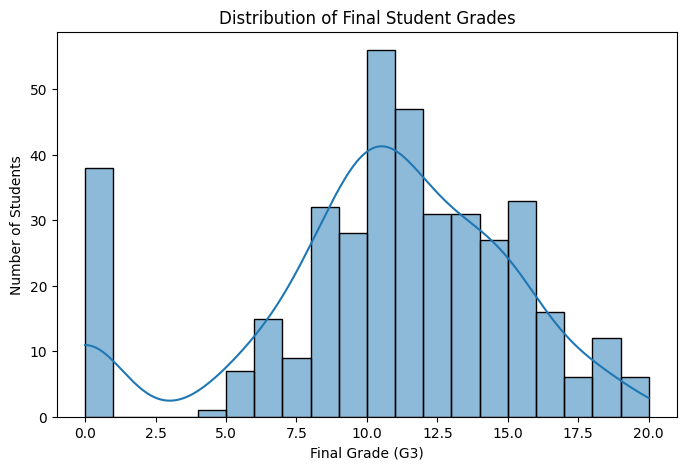

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df_math['G3'], bins=20, kde=True)

plt.title('Distribution of Final Student Grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')

plt.show()

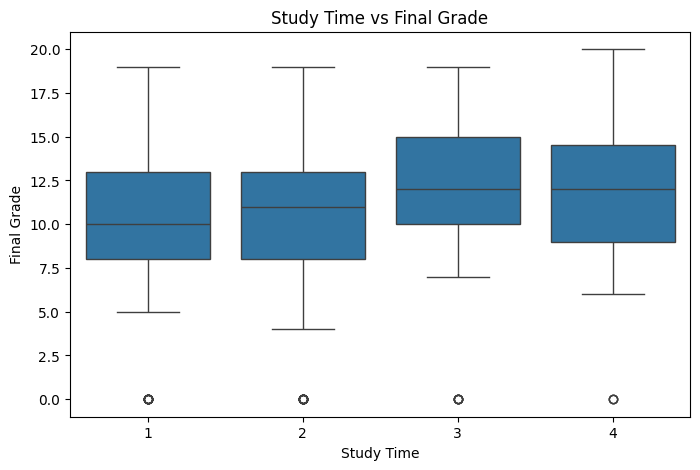

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x='studytime', y='G3', data=df_math)

plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')

plt.show()

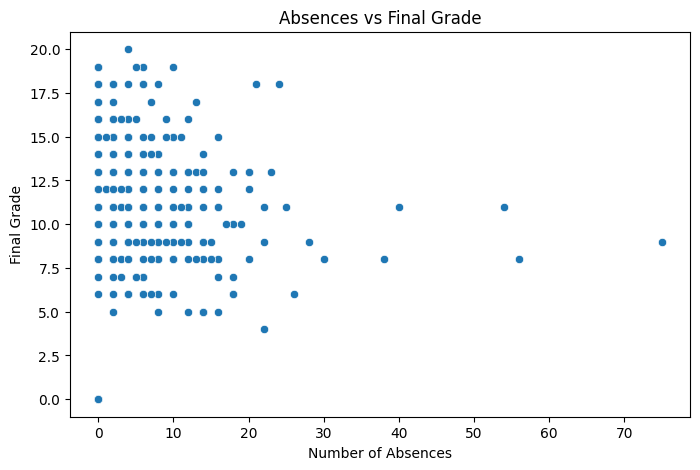

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='absences',
    y='G3',
    data=df_math
)

plt.title('Absences vs Final Grade')
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade')

plt.show()

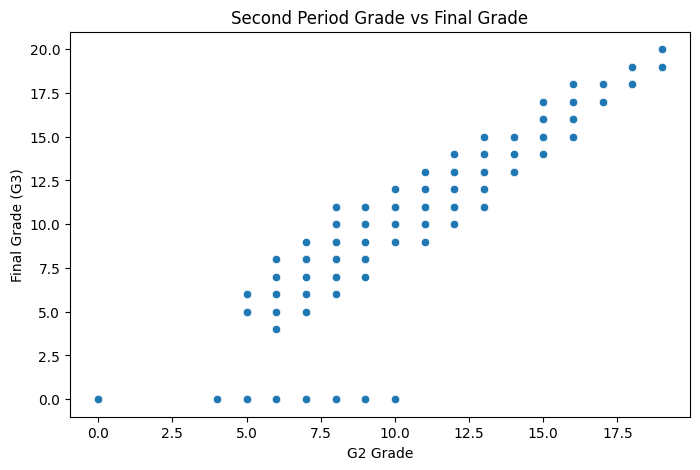

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='G2',
    y='G3',
    data=df_math
)

plt.title('Second Period Grade vs Final Grade')
plt.xlabel('G2 Grade')
plt.ylabel('Final Grade (G3)')

plt.show()

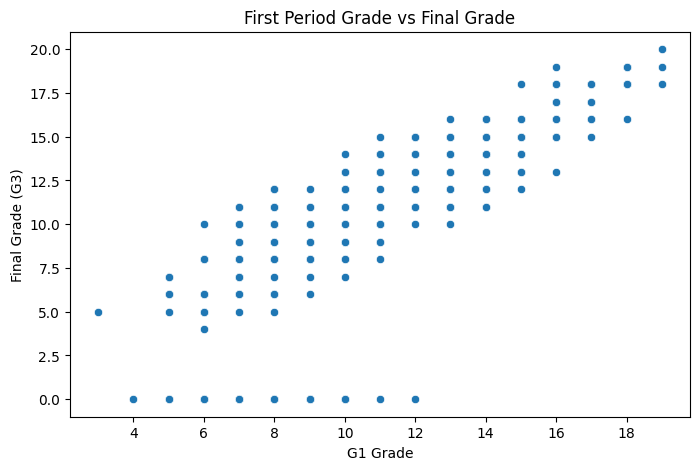

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='G1',
    y='G3',
    data=df_math
)

plt.title('First Period Grade vs Final Grade')
plt.xlabel('G1 Grade')
plt.ylabel('Final Grade (G3)')

plt.show()

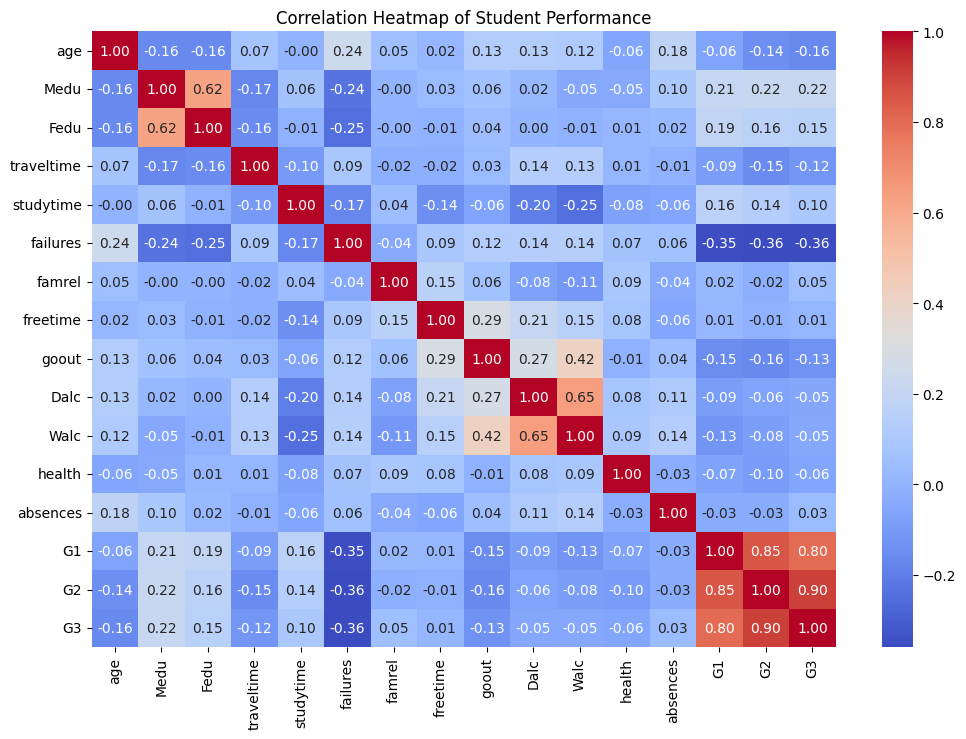

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_math.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Student Performance')

plt.show()

In [33]:
y = df_math['G3']

In [34]:
X = df_math.drop('G3', axis=1)

In [35]:
categorical_features = X.select_dtypes(include=['object']).columns

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

Numerical Features:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')


In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [39]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [40]:
y_pred_linear = linear_model.predict(X_test)

In [41]:
rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

In [42]:
r2_linear = r2_score(
    y_test,
    y_pred_linear
)

In [43]:
print("Linear Regression RMSE:", rmse_linear)
print("Linear Regression R²:", r2_linear)

Linear Regression RMSE: 2.3783697847961367
Linear Regression R²: 0.7241341236974022


In [44]:
decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            random_state=42
        ))
    ]
)

In [46]:
decision_tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object'))])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [47]:
y_pred_tree = decision_tree_model.predict(X_test)

In [48]:
rmse_tree = np.sqrt(
    mean_squared_error(y_test, y_pred_tree)
)

r2_tree = r2_score(
    y_test,
    y_pred_tree
)

print("Decision Tree RMSE:", rmse_tree)
print("Decision Tree R²:", r2_tree)

Decision Tree RMSE: 2.570524253281587
Decision Tree R²: 0.6777576344825431


In [49]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regression'
    ],
    'RMSE': [
        rmse_linear,
        rmse_tree
    ],
    'R2 Score': [
        r2_linear,
        r2_tree
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,2.378370,0.724134
1,Decision Tree Regression,2.570524,0.677758


In [51]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results)

https://docs.google.com/spreadsheets/d/16EVpoiAg0LSMz3xtlvUUoK6Id54qKZ8mKNdhAYrTjVA/edit#gid=0


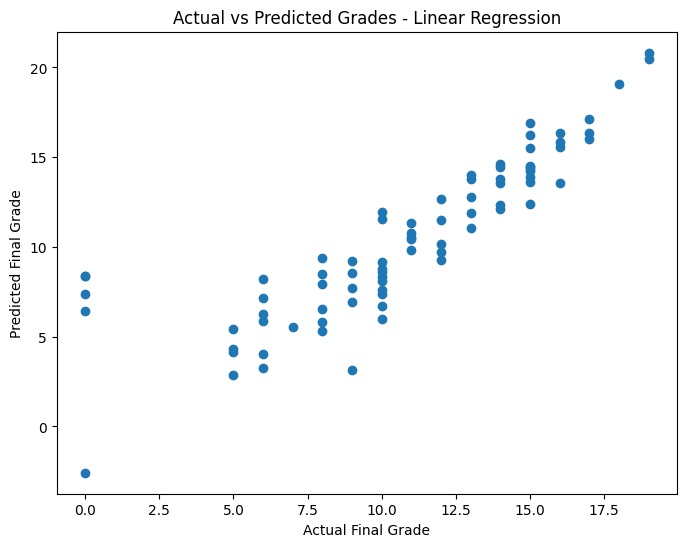

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_linear
)

plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade')

plt.title('Actual vs Predicted Grades - Linear Regression')

plt.show()

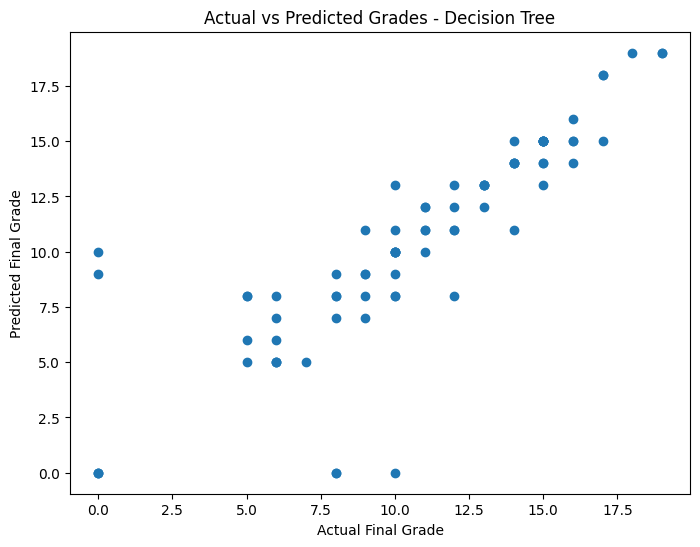

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_tree
)

plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade')

plt.title('Actual vs Predicted Grades - Decision Tree')

plt.show()

In [54]:
comparison = pd.DataFrame({
    'Actual G3': y_test.values,
    'Linear Regression Prediction': y_pred_linear,
    'Decision Tree Prediction': y_pred_tree
})

comparison.head(10)

,Actual G3,Linear Regression Prediction,Decision Tree Prediction
0,10,6.001607,8.0
1,12,11.528478,12.0
2,5,2.866437,8.0
3,10,8.796631,10.0
4,9,8.553106,9.0
5,13,11.889641,13.0
6,18,19.096742,19.0
7,6,7.173079,5.0
8,0,7.405071,9.0
9,14,12.311537,14.0


In [65]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=comparison)

https://docs.google.com/spreadsheets/d/1ZHq7e3rlFohsKnnIwMZqgWP7-7EPcdU6Jqxn7dQuq38/edit#gid=0


In [55]:
preprocessor_fitted = decision_tree_model.named_steps['preprocessor']

In [56]:
feature_names = preprocessor_fitted.get_feature_names_out()

In [57]:
importance = decision_tree_model.named_steps[
    'model'
].feature_importances_

In [58]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,num__G2,0.738286
12,num__absences,0.154572
36,cat__reason_home,0.034511
43,cat__schoolsup_yes,0.015626
0,num__age,0.013095
32,cat__Fjob_other,0.008648
4,num__studytime,0.004846
10,num__Walc,0.003966
13,num__G1,0.003498
1,num__Medu,0.003493


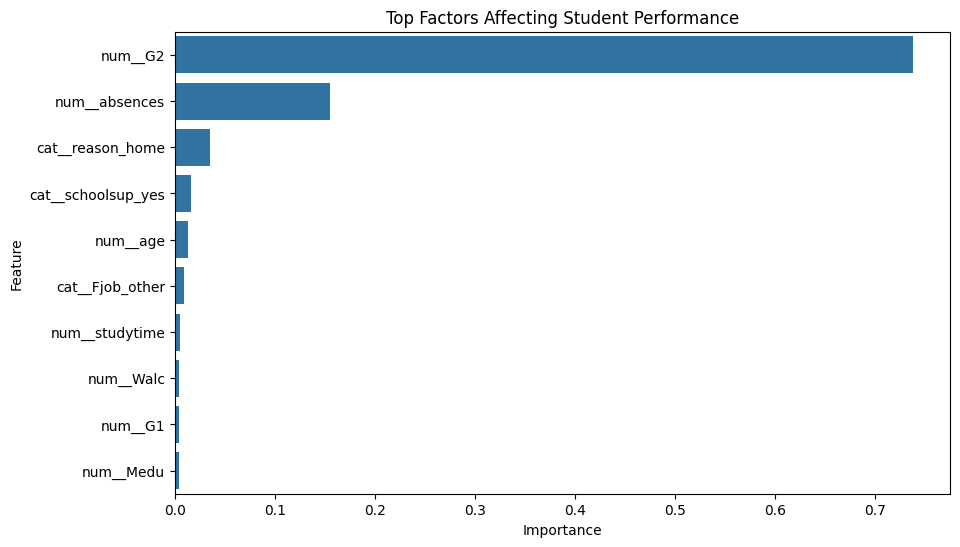

In [59]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top Factors Affecting Student Performance')

plt.show()

In [60]:
df_por = pd.read_csv(
    '/content/student-por.csv',
    sep=';'
)

In [61]:
df_por.shape

(649, 33)

In [62]:
df_por.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [63]:
df_por.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [64]:
def predict_student_performance(model, student_data):
    prediction = model.predict(student_data)
    return prediction[0]